## Pneumonia Detection - Model Analysis Visualization

**Authors**: Aye Nyein Kyaw and Isiah Ketton  
**Course**: CS 171 - Machine Learning  
**Project**: Pneumonia Detection from Chest X-Ray Images

This notebook implements and trains a Convolutional Neural Network (CNN) for pneumonia detection.

We will:
1. Define the ResNet
2. Finetune/Train the ResNet with validation monitoring
3. Train the model with validation monitoring
4. Save the best model checkpoint
5. Evaluate on the test set

**Prerequisites**: Run `data_preprocessing.ipynb` first to prepare the data.

In [1]:
#!pip install grad-cam

import torch
from torchvision import datasets
import json
import time
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score, classification_report, precision_score
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import seaborn as sns
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from datetime import datetime

# Import Grad-CAM tools
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA")
elif torch.backends.mps.is_available():  # For Apple Silicon Macs
    device = torch.device("mps")
    print("MPS")
else:
    device = torch.device("cpu")
    print("CPU")

MPS


In [3]:


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Visualization style configured")



Visualization style configured


## Load Preprocessed Data

Load the DataLoaders created in the preprocessing notebook. IMPORTANT: Run data_preprocessing.ipynb first!


In [4]:


print("=== LOADING PREPROCESSED DATA ===")

try:
    # Method 1: Import directly if running in same session
    from data_preprocessing import train_loader, val_loader, test_loader, device
    print("DataLoaders loaded from preprocessing notebook")
    
    # Get class names from the dataset
    from data_preprocessing import train_dataset
    CLASS_NAMES = train_dataset.classes
    print(f"Class names loaded: {CLASS_NAMES}")
    
except ImportError:
    print("Could not import from preprocessing notebook.")
    print("Trying alternative loading method...")
    
    # Method 2: Load from saved config and recreate
    try:
        # Load preprocessing configuration
        with open('preprocessing_config.json', 'r') as f:
            config = json.load(f)
        
        print("Loaded preprocessing configuration")
        
        # Extract information
        IMAGE_SIZE = config['image_settings']['size']
        BATCH_SIZE = config['data_settings']['batch_size']
        CLASS_NAMES = config['class_info']['classes']
        
        # Recreate transforms
        from torchvision import transforms
        
        basic_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        
        
        train_dir = config['paths']['train_dir']
        val_dir = config['paths']['val_dir']
        test_dir = config['paths']['test_dir']
        
        train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
        val_dataset = datasets.ImageFolder(val_dir, transform=basic_transform)
        test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)
        
        # Create DataLoaders
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        print("DataLoaders recreated from config")
        
    except Exception as e:
        print(f"Error: {e}")
        print("\nPlease run 'data_preprocessing.ipynb' first!")
        raise



=== LOADING PREPROCESSED DATA ===
Could not import from preprocessing notebook.
Trying alternative loading method...
Loaded preprocessing configuration
DataLoaders recreated from config


# Load ResNet18 model

In [5]:
num_classes = 2 

# Load the base ResNet18 architecture
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/jennicawangyulan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████| 44.7M/44.7M [00:09<00:00, 4.73MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Define Training Utilities

In [6]:
def compute_metrics(outputs, labels):
    """
    Compute accuracy metrics for a batch.
    
    Args:
        outputs (Tensor): Model predictions [batch_size, num_classes]
        labels (Tensor): Ground truth labels [batch_size]
    
    Returns:
        tuple: (correct_count, total_count, predictions)
    """
    # Get predicted class (index with highest score)
    _, predicted = torch.max(outputs.data, 1)
    
    # Count correct predictions
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    
    return correct, total, predicted.cpu().numpy()

def calculate_class_weights(train_loader):
    """
    Calculate class weights for imbalanced datasets.
    
    Args:
        train_loader: DataLoader for training data
    
    Returns:
        Tensor: Class weights for loss function
    """
    # Count samples per class
    class_counts = torch.zeros(2)  # We have 2 classes
    
    for _, labels in train_loader:
        for i in range(2):
            class_counts[i] += (labels == i).sum().item()
    
    # Calculate weights (inverse frequency)
    total = class_counts.sum()
    weights = total / (2 * class_counts)  # 2 is number of classes
    
    # Normalize weights
    weights = weights / weights.sum() * 2
    
    print(f"Class counts: NORMAL={class_counts[0]:.0f}, PNEUMONIA={class_counts[1]:.0f}")
    print(f"Class weights: {weights.tolist()}")

# Set Up Training Configuration

In [7]:


print("TRAINING CONFIGURATION")


# 1. LOSS FUNCTION
# For imbalanced datasets, we can use weighted loss
print("\n1. Setting up loss function...")

# Calculate class weights ( to helps with imbalanced data)
try:
    class_weights = calculate_class_weights(train_loader)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print(f" Using weighted CrossEntropyLoss")
except:
    criterion = nn.CrossEntropyLoss()
    print(f" Using standard CrossEntropyLoss")


# 2. OPTIMIZER

print("\n2. Setting up optimizer...")
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f" Using Adam optimizer with LR={LEARNING_RATE}")


# 3. LEARNING RATE SCHEDULER
# Reduces learning rate when validation loss stops improving
print("\n3. Setting up learning rate scheduler...")
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',      # Minimize validation loss
    factor=0.5,      # Reduce LR by half
    patience=3,      # Wait 3 epochs without improvement
    # verbose=True     # Print when LR changes
)
print(" LR scheduler: ReduceLROnPlateau(factor=0.5, patience=3)")


# 4. TRAINING PARAMETERS
print("\n4. Setting training parameters...")
NUM_EPOCHS = 20
PRINT_EVERY = 1  # Print stats every N epochs
SAVE_BEST = True  # Save best model based on validation accuracy

print(f" Number of epochs: {NUM_EPOCHS}")
print(f" Print every: {PRINT_EVERY} epoch(s)")
print(f" Save best model: {SAVE_BEST}")


# 5. TRACKING VARIABLES

print("\n5. Initializing tracking variables...")

# For tracking training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'learning_rate': []
}

# For saving best model
best_val_acc = 0.0
best_epoch = 0

print(" All training configuration complete!")



TRAINING CONFIGURATION

1. Setting up loss function...
Class counts: NORMAL=1341, PNEUMONIA=3875
Class weights: [1.4858129024505615, 0.5141871571540833]
 Using weighted CrossEntropyLoss

2. Setting up optimizer...
 Using Adam optimizer with LR=0.001

3. Setting up learning rate scheduler...
 LR scheduler: ReduceLROnPlateau(factor=0.5, patience=3)

4. Setting training parameters...
 Number of epochs: 20
 Print every: 1 epoch(s)
 Save best model: True

5. Initializing tracking variables...
 All training configuration complete!


# Define Training Loop Functions

In [8]:
from tqdm.auto import tqdm
TQDM_AVAILABLE = True

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Returns:
        tuple: (average_loss, accuracy)
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    # Progress bar for training
    if TQDM_AVAILABLE:
        loader = tqdm(train_loader, desc="Training")
    else:
        loader = train_loader
        print("Training...")
    
    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Calculate metrics
        correct, total, _ = compute_metrics(outputs, labels)
        
        # Update running totals
        running_loss += loss.item()
        running_correct += correct
        running_total += total
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = running_correct / running_total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """
    Validate the model on validation set.
    
    Returns:
        tuple: (loss, accuracy, precision, recall, f1)
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    
    # Store all predictions and labels for metrics
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():  # No gradient calculation for validation
        if TQDM_AVAILABLE:
            loader = tqdm(val_loader, desc="Validation")
        else:
            loader = val_loader
            print("Validating...")
        
        for images, labels in loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Calculate metrics
            correct, total, predictions = compute_metrics(outputs, labels)
            
            # Update running totals
            running_loss += loss.item()
            running_correct += correct
            running_total += total
            
            # Store for overall metrics
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions)
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = running_correct / running_total
    
    # Calculate additional metrics
    if len(all_labels) > 0:
        epoch_precision = precision_score(all_labels, all_predictions, average='weighted')
        epoch_recall = recall_score(all_labels, all_predictions, average='weighted')
        epoch_f1 = f1_score(all_labels, all_predictions, average='weighted')
    else:
        epoch_precision = epoch_recall = epoch_f1 = 0.0
    
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1

# Main Training/Finetuning Loop

In [9]:
print("STARTING TRAINING")
print(f"Training on: {device}")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

# Training loop
for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    

    # TRAINING PHASE

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    

    # VALIDATION PHASE

    val_loss, val_acc, val_precision, val_recall, val_f1 = validate(
        model, val_loader, criterion, device
    )
    

    # UPDATE SCHEDULER
    scheduler.step(val_loss)
    

    # STORE HISTORY
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    

    # SAVE BEST MODEL

    if SAVE_BEST and val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        
        # Save model checkpoint
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'history': history,
            'config': {
                'num_epochs': NUM_EPOCHS,
                'learning_rate': LEARNING_RATE,
                'dropout_rate': 0.5,
                'best_val_acc': best_val_acc
            }
        }
        
        torch.save(checkpoint, 'finetuned_resnet.pth')
        
        if PRINT_EVERY > 0:
            print(f"   Saved new best model! (Val Acc: {val_acc:.4f})")
    

    # PRINT PROGRESS

    if (epoch + 1) % PRINT_EVERY == 0:
        epoch_time = time.time() - epoch_start_time
        
        print(f"\nEpoch {epoch+1:3d}/{NUM_EPOCHS} | Time: {epoch_time:.1f}s")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print(f"  Precision:  {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
        print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        
        if val_acc == best_val_acc:
            print(f"   BEST SO FAR (epoch {epoch+1})")
    
    # Early stopping check (optional)
    if optimizer.param_groups[0]['lr'] < 1e-6:
        print(f"\n  Learning rate very low. Stopping early.")
        break

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Best validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Model saved as: 'finetuned_resnet.pth'")

STARTING TRAINING
Training on: mps
Start time: 2026-05-12 11:13:51



Training:   0%|          | 0/163 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

   Saved new best model! (Val Acc: 0.7500)

Epoch   1/20 | Time: 206.7s
  Train Loss: 0.1195 | Train Acc: 0.9534
  Val Loss:   0.4517 | Val Acc:   0.7500
  Precision:  0.8333 | Recall: 0.7500 | F1: 0.7333
  Learning Rate: 0.001000
   BEST SO FAR (epoch 1)


Training:   0%|          | 0/163 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch  19/20 | Time: 130.4s
  Train Loss: 0.0002 | Train Acc: 1.0000
  Val Loss:   0.0306 | Val Acc:   1.0000
  Precision:  1.0000 | Recall: 1.0000 | F1: 1.0000
  Learning Rate: 0.000125
   BEST SO FAR (epoch 19)


Training:   0%|          | 0/163 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch  20/20 | Time: 136.2s
  Train Loss: 0.0002 | Train Acc: 1.0000
  Val Loss:   0.0118 | Val Acc:   1.0000
  Precision:  1.0000 | Recall: 1.0000 | F1: 1.0000
  Learning Rate: 0.000125
   BEST SO FAR (epoch 20)

TRAINING COMPLETE!
End time: 2026-05-12 12:04:05
Best validation accuracy: 1.0000 (epoch 3)
Model saved as: 'finetuned_resnet.pth'


# Visualize Training History

Plotting simplified training history...


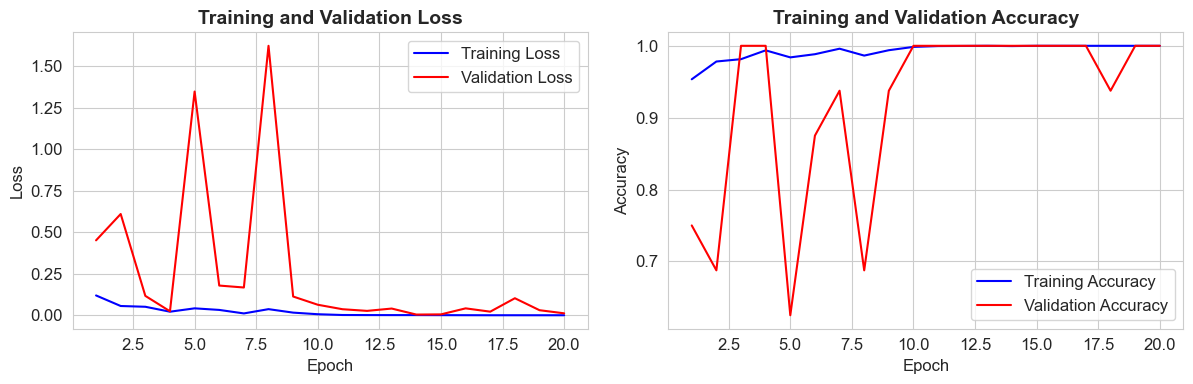

Final Training Loss: 0.0002
Final Validation Loss: 0.0118
Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000


In [10]:
def plot_training_history_simple(history):
    """Simpler plot like professor's style."""
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Create figure with 2 subplots (like professor)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
    print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")

# Use the simpler version
print("Plotting simplified training history...")
plot_training_history_simple(history)

# Load Best Model for Evaluation

In [11]:
print("=== LOADING BEST MODEL ===")
NUM_CLASSES = 2
try:
    # Load checkpoint
    checkpoint = torch.load('finetuned_resnet.pth', map_location=device)
    
    # Create new model instance
    best_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES)

    best_model.to(device)
    
    # Load trained weights
    best_model.load_state_dict(checkpoint['model_state_dict'])
    
    # Get best epoch info
    best_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['val_acc']
    
    print(f"✓ Best model loaded successfully!")
    print(f"  From epoch: {best_epoch}")
    print(f"  Validation accuracy: {best_val_acc:.4f}")
    
    # Update our current model to the best one
    model = best_model
    
except FileNotFoundError:
    print("No saved model found. Using current model.")
    best_epoch = NUM_EPOCHS
    best_val_acc = history['val_acc'][-1]

print(f"Model ready for evaluation.")


=== LOADING BEST MODEL ===
✓ Best model loaded successfully!
  From epoch: 3
  Validation accuracy: 1.0000
Model ready for evaluation.


# Evaluate ResNet Performance


FINAL TEST SET EVALUATION
Evaluating on test set...

TEST SET PERFORMANCE
Test Loss: 0.3228
Test Accuracy: 0.9006 (562/624)

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9886    0.7436    0.8488       234
   PNEUMONIA     0.8661    0.9949    0.9260       390

    accuracy                         0.9006       624
   macro avg     0.9274    0.8692    0.8874       624
weighted avg     0.9120    0.9006    0.8971       624



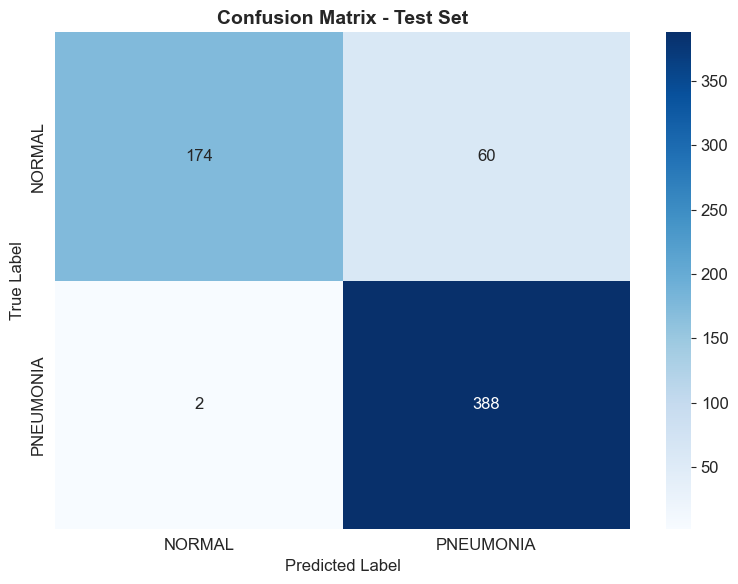


Per-class accuracy:
  NORMAL: 0.7436
  PNEUMONIA: 0.9949


In [12]:
def evaluate_on_test_set(model, test_loader, device):
    """
    Evaluate model on test set and return comprehensive metrics.
    """
    model.eval()
    
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    print("Evaluating on test set...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            # Get predictions
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            # Update counts
            correct = (predicted == labels).sum().item()
            test_correct += correct
            test_total += labels.size(0)
            
            # Store for overall metrics
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Calculate metrics
    test_loss = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    
    # Classification report
    print("\n" + "="*60)
    print("TEST SET PERFORMANCE")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f} ({test_correct}/{test_total})")
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, 
                               target_names=CLASS_NAMES, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Calculate per-class accuracy
    print("\nPer-class accuracy:")
    for i, class_name in enumerate(CLASS_NAMES):
        class_mask = np.array(all_labels) == i
        if class_mask.any():
            class_acc = np.mean(np.array(all_predictions)[class_mask] == i)
            print(f"  {class_name}: {class_acc:.4f}")
    
    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_correct': test_correct,
        'test_total': test_total,
        'confusion_matrix': cm,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }

# Run evaluation
print("\n" + "="*70)
print("FINAL TEST SET EVALUATION")

test_results = evaluate_on_test_set(model, test_loader, device)

The ResNet when compared to our CNN model is much more performant on normal class cases. This can be seen in our accuracy and precision cases and is most obvious in our depicted confusion matrix. The top left and bottom rigt are indicators for number of correct cases and when compared to our CNN's confusion matrix, ResNet have a lot more true cases for normal.

# Visualize ResNet Predictions


VISUALIZING MODEL PREDICTIONS


/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/1962109684.py:64: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/1962109684.py:64: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


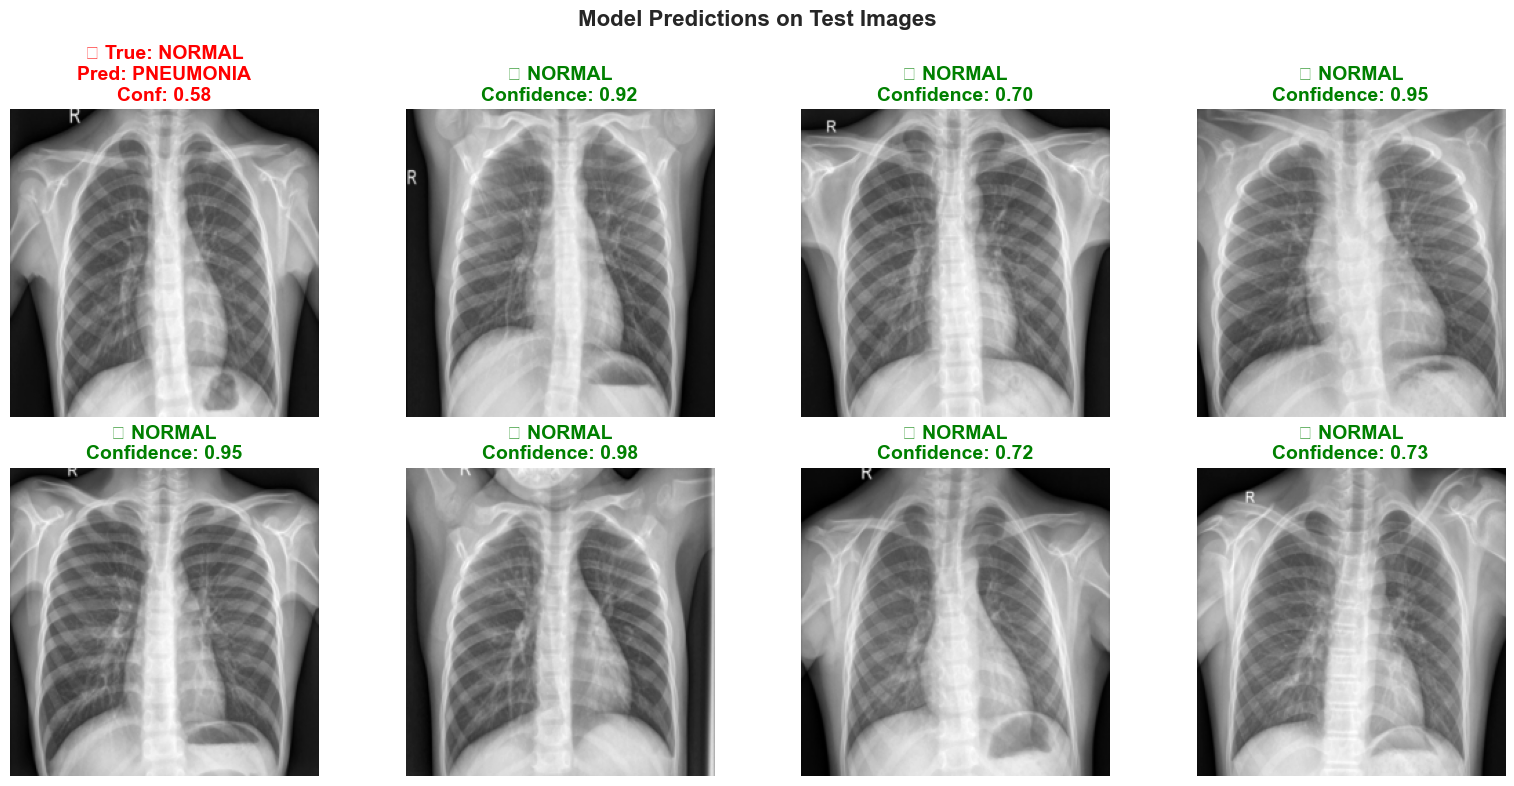

Displayed 8 examples:
  Correct predictions: 7
  Incorrect predictions: 1


In [13]:
def visualize_predictions(model, test_loader, device, num_examples=8):
    """
    Visualize model predictions on test images.
    """
    model.eval()
    
   
    images, labels = next(iter(test_loader))
    images = images.to(device)
    labels = labels.to(device)
    
    
    with torch.no_grad():
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)
    
   
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    probabilities = probabilities.cpu()
    
  
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(min(num_examples, len(images))):
        
        img = images[i]
        true_label = labels[i].item()
        pred_label = predictions[i].item()
        prob = probabilities[i][pred_label].item()
        
       
        img_display = img.numpy().transpose((1, 2, 0))
        img_display = img_display * 0.5 + 0.5  
        img_display = np.clip(img_display, 0, 1)
        
       
        axes[i].imshow(img_display[:, :, 0], cmap='gray')
        
      
        true_name = CLASS_NAMES[true_label]
        pred_name = CLASS_NAMES[pred_label]
        
        if true_label == pred_label:
      
            title_color = 'green'
            title = f"✓ {true_name}\nConfidence: {prob:.2f}"
        else:
   
            title_color = 'red'
            title = f"✗ True: {true_name}\nPred: {pred_name}\nConf: {prob:.2f}"
        
        axes[i].set_title(title, color=title_color, fontweight='bold')
        axes[i].axis('off')
    

    for i in range(min(num_examples, len(images)), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    

    num_correct = sum(1 for i in range(min(num_examples, len(images))) 
                      if labels[i].item() == predictions[i].item())
    
    print(f"Displayed {min(num_examples, len(images))} examples:")
    print(f"  Correct predictions: {num_correct}")
    print(f"  Incorrect predictions: {min(num_examples, len(images)) - num_correct}")

print("\n" + "="*70)
print("VISUALIZING MODEL PREDICTIONS")
print("="*70)
visualize_predictions(model, test_loader, device, num_examples=8)

We can see when compared to the visualizations in model_training, that the ResNet performs much better overall on normal cases. 

In [14]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("SAVING FINAL RESULTS")

# Create results dictionary
final_results = {
    'training_info': {
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_results['test_acc'],
        'test_loss': test_results['test_loss'],
        'training_time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    
    'model_info': {
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'architecture': str(model).split('\n')[0],  
        'input_size': (3, IMAGE_SIZE, IMAGE_SIZE),
        'num_classes': 2
    },
    
    'hyperparameters': {
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'dropout_rate': 0.5,
        'optimizer': 'Adam',
        'loss_function': 'CrossEntropyLoss'
    },
    
    'metrics': {
        'confusion_matrix': test_results['confusion_matrix'].tolist(),
        'test_correct': int(test_results['test_correct']),
        'test_total': int(test_results['test_total']),
        'per_class_accuracy': {
            CLASS_NAMES[0]: test_results['confusion_matrix'][0,0] / test_results['confusion_matrix'][0,:].sum(),
            CLASS_NAMES[1]: test_results['confusion_matrix'][1,1] / test_results['confusion_matrix'][1,:].sum()
        }
    },
    
    'training_history': history
}

# Save to JSON file
results_file = 'resnet_finetuning_results.json'
with open(results_file, 'w') as f:
    json.dump(final_results, f, indent=2)

print(f" Results saved to '{results_file}'")

summary_file = 'resnet_summary.txt'
with open(summary_file, 'w') as f:
    f.write("="*60 + "\n")
    f.write("PNEUMONIA DETECTION RESNET - TRAINING SUMMARY\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"RESNET PERFORMANCE\n")
    f.write(f"{'='*40}\n")
    f.write(f"Best Validation Accuracy: {best_val_acc:.4f} (epoch {best_epoch})\n")
    f.write(f"Test Accuracy: {test_results['test_acc']:.4f}\n")
    f.write(f"Test Loss: {test_results['test_loss']:.4f}\n")
    f.write(f"Correct/Total: {test_results['test_correct']}/{test_results['test_total']}\n\n")
    
    f.write(f"RESNET ARCHITECTURE\n")
    f.write(f"{'='*40}\n")
    f.write(f"Total Parameters: {total_params:,}\n")
    f.write(f"Trainable Parameters: {trainable_params:,}\n")
    f.write(f"Input Size: 3 x {IMAGE_SIZE} x {IMAGE_SIZE}\n")
    f.write(f"Output Classes: {CLASS_NAMES}\n\n")
    
    f.write(f"TRAINING CONFIGURATION\n")
    f.write(f"{'='*40}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Dropout Rate: 0.5\n")
    f.write(f"Optimizer: Adam\n")
    f.write(f"Device: {device}\n")

print(f" Summary saved to '{summary_file}'")

SAVING FINAL RESULTS
 Results saved to 'resnet_finetuning_results.json'
 Summary saved to 'resnet_summary.txt'


## Grad Cam Visualization

Generating Grad-CAM for 8 RANDOM images...


/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/3834632891.py:71: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/3834632891.py:71: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


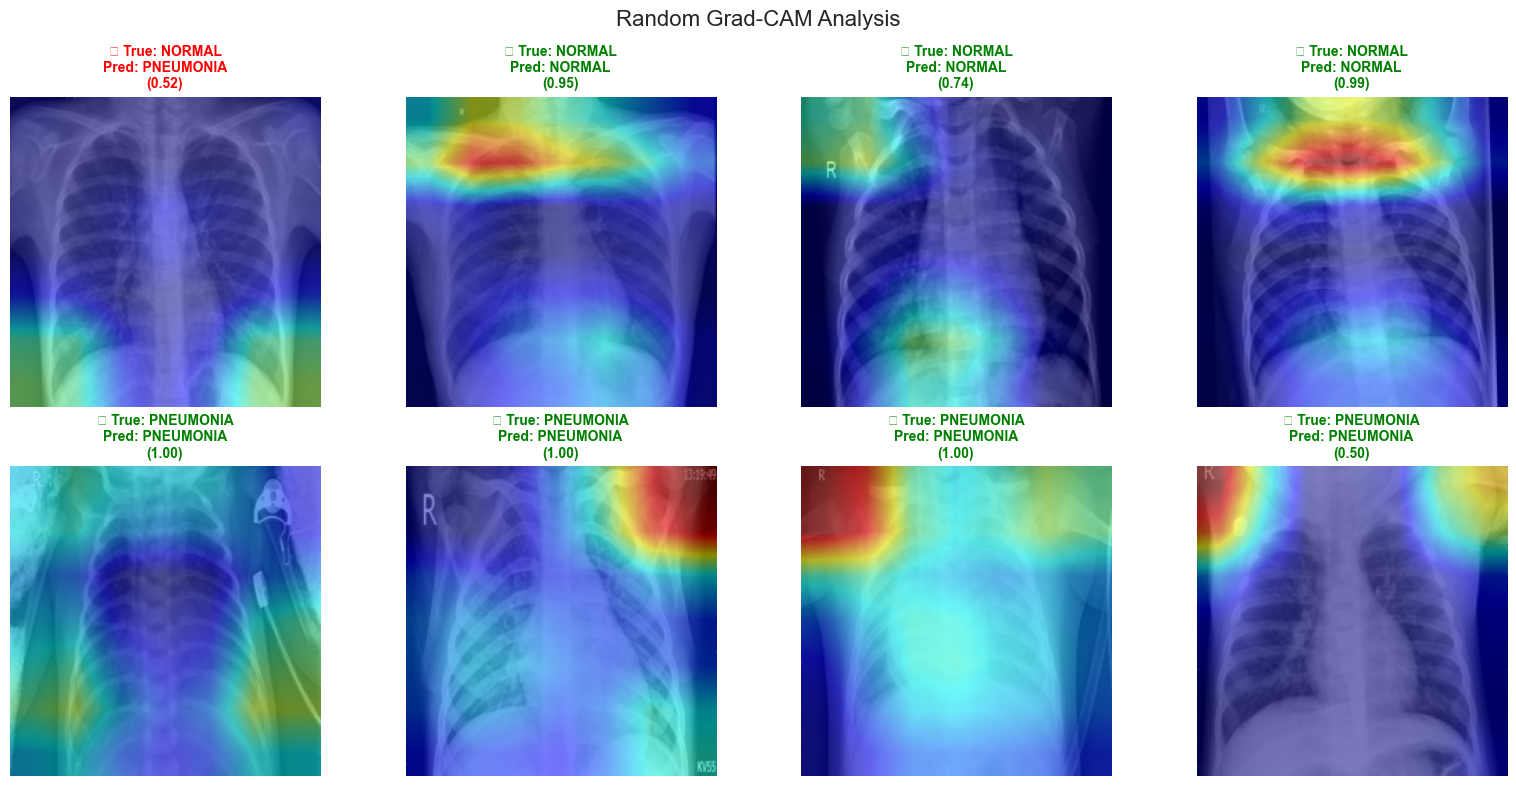

In [15]:
from torch.utils.data import DataLoader

def visualize_gradcam_random(model, dataset, device, num_rows=2, images_per_row=4):
    """
    Visualizes Grad-CAM for RANDOM images from the dataset every time it runs.
    """
    model.eval()
    

    num_examples = num_rows * images_per_row
    random_loader = DataLoader(dataset, batch_size=num_examples, shuffle=True)
    

    try:
        target_layers = [model.layer4[-1]]
    except AttributeError:

        print("Warning: Defaulting to ResNet layer. Update code if using CNN.")
        return

    cam = GradCAM(model=model, target_layers=target_layers)


    images, labels = next(iter(random_loader))
    images = images.to(device)
    labels = labels.to(device)


    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(4 * images_per_row, 4 * num_rows))
    axes = axes.ravel()

    print(f"Generating Grad-CAM for {num_examples} RANDOM images...")

    for i in range(num_examples):
        img_tensor = images[i].unsqueeze(0) 
        true_label = labels[i].item()

        with torch.no_grad():
            output = model(img_tensor)
            probabilities = F.softmax(output, dim=1)
            pred_score, pred_label_tensor = torch.max(probabilities, 1)
            pred_label = pred_label_tensor.item()
            prob = pred_score.item()

        targets = [ClassifierOutputTarget(pred_label)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets, aug_smooth=True)
        
        rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * 0.5 + 0.5 
        rgb_img = np.clip(rgb_img, 0, 1)

        visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)

        ax = axes[i]
        ax.imshow(visualization)
        
        true_name = CLASS_NAMES[true_label]
        pred_name = CLASS_NAMES[pred_label]
        
        if true_label == pred_label:
            color = 'green'
            title = f"✓ True: {true_name}\nPred: {pred_name}\n({prob:.2f})"
        else:
            color = 'red'
            title = f"✗ True: {true_name}\nPred: {pred_name}\n({prob:.2f})"
            
        ax.set_title(title, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Random Grad-CAM Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_gradcam_random(model, test_dataset, device)

For ResNet's grad cam visualizations, we can see the model have a fairly focused look on what it considers normal cases and what it considers pnuemonia cases. ResNet tends to think that pneumonia signs are located in the lower left/right abdomen. In cases where it considers a case normal, the focus of attention is typically everywhere else.

# Grad Cam for CNN Model

In [16]:
class PneumoniaCNN(nn.Module):
    """
    Convolutional Neural Network for Pneumonia Detection.
    
    Architecture:
    - Input: 3x224x224 image
    - 4 Conv Blocks (Conv → BatchNorm → ReLU → MaxPool)
    - 2 Fully Connected Layers with Dropout
    - Output: 2 classes (NORMAL, PNEUMONIA)
    
    Total parameters: ~3.5 million
    """

    def __init__(self, dropout_rate=0.5):
        """
        Initialize the CNN.
        
        Args:
            dropout_rate (float): Probability for dropout layers (0.0-1.0)
        """
        super(PneumoniaCNN, self).__init__()
        
        # CONVOLUTIONAL BLOCKS
        
        # Block 1: Input (3, 224, 224) → Output (32, 112, 112)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32 filters, 3x3 kernel
            nn.BatchNorm2d(32),  # Normalize activations
            nn.ReLU(inplace=True),  # Non-linear activation
            nn.MaxPool2d(kernel_size=2, stride=2)  # Reduce size by half
        )

        
        # Block 2: Input (32, 112, 112) → Output (64, 56, 56)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        
        # Block 3: Input (64, 56, 56) → Output (128, 28, 28)
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )


        
        # Block 4: Input (128, 28, 28) → Output (256, 14, 14)
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        

        # FULLY CONNECTED LAYERS
        
        # Calculate size after convolutions
        # 224 → 112 → 56 → 28 → 14 (after 4 maxpool layers)
        # So: 14x14 spatial size with 256 channels
        self.flattened_size = 256 * 14 * 14
        
        self.fc_layers = nn.Sequential(
            # Flatten 3D feature maps to 1D vector
            nn.Flatten(),
            
            # First fully connected layer
            nn.Linear(self.flattened_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),  # Prevent overfitting
            
            # Second fully connected layer
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate * 0.8),  # Slightly less dropout
            
            # Output layer (2 classes)
            nn.Linear(256, 2)
        )
        
        # Initialize weights for better training
        self._initialize_weights()

        
    def _initialize_weights(self):
        """Initialize weights using Kaiming initialization for ReLU."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x (Tensor): Input batch of images [batch_size, 3, 224, 224]
        
        Returns:
            Tensor: Output logits [batch_size, 2]
        """
        # Pass through convolutional blocks
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Pass through fully connected layers
        x = self.fc_layers(x)
        
        return x


    
    def count_parameters(self):
        """Count total and trainable parameters."""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total_params, trainable_params

In [17]:
print("=== LOADING BEST MODEL ===")

try:

    checkpoint = torch.load('best_pneumonia_model.pth', map_location=device)

    best_model = PneumoniaCNN(dropout_rate=0.5).to(device)
    

    best_model.load_state_dict(checkpoint['model_state_dict'])

    best_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['val_acc']
    
    print(f"✓ Best model loaded successfully!")
    print(f"  From epoch: {best_epoch}")
    print(f"  Validation accuracy: {best_val_acc:.4f}")
    

    model = best_model
    
except FileNotFoundError:
    print("  No saved model found. Using current model.")
    best_epoch = NUM_EPOCHS
    best_val_acc = history['val_acc'][-1]

print(f"Model ready for evaluation.")

=== LOADING BEST MODEL ===
✓ Best model loaded successfully!
  From epoch: 13
  Validation accuracy: 0.9809
Model ready for evaluation.


Generating Grad-CAM for 8 RANDOM images using layer 'Sequential'...


/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/3745910432.py:78: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/cm/87xs3xzs13qcmdnys2_jq0cc0000gn/T/ipykernel_94155/3745910432.py:78: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()


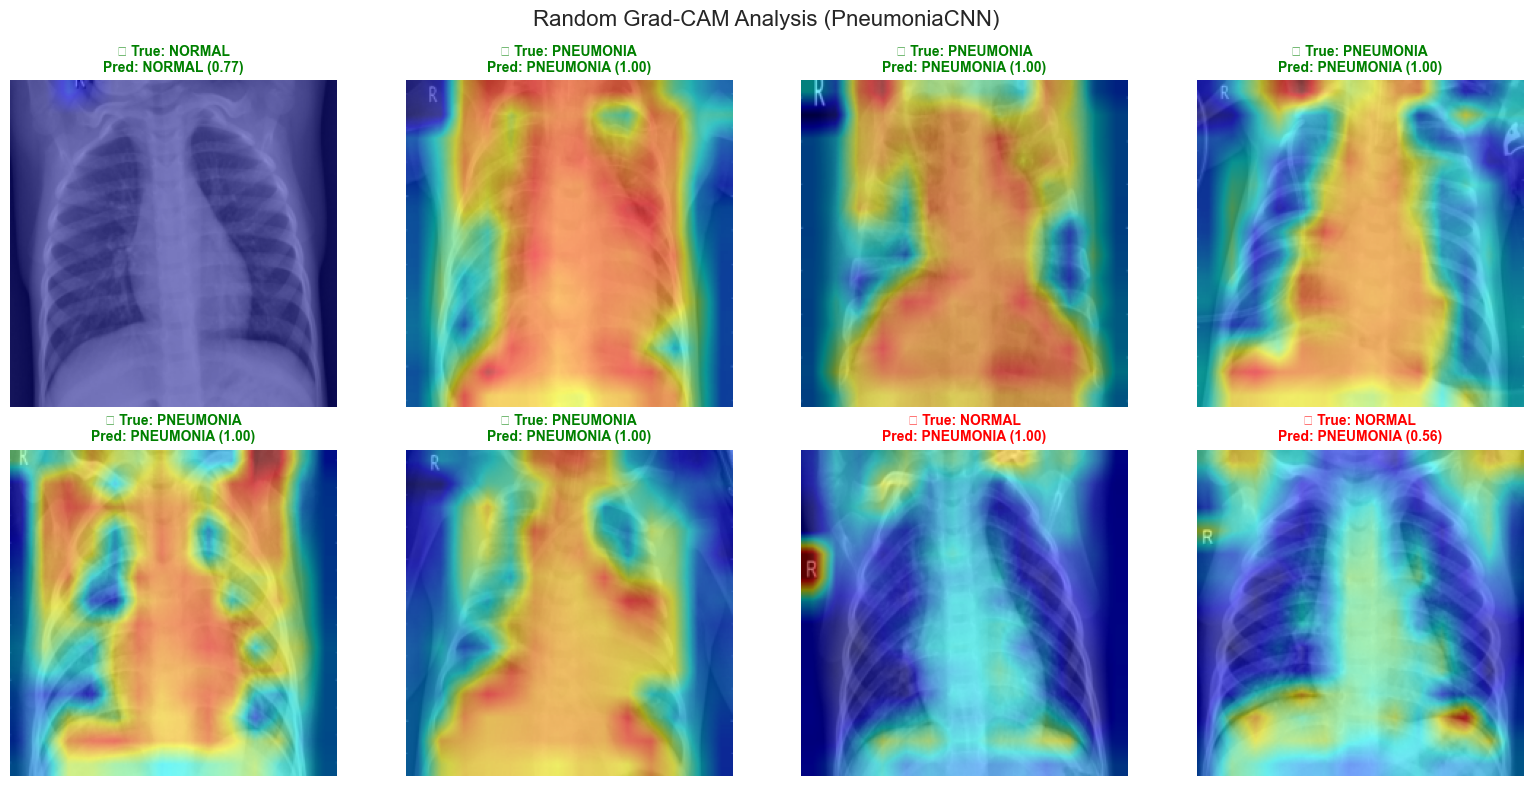

In [18]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


def visualize_gradcam_random(model, dataset, device, num_rows=2, images_per_row=4):
    """
    Visualizes Grad-CAM for RANDOM images from the dataset every time it runs,
    using the last convolutional layer of the PneumoniaCNN model.
    """
    model.eval()
    

    target_layers = [model.conv4] 
    
    num_examples = num_rows * images_per_row
    random_loader = DataLoader(dataset, batch_size=num_examples, shuffle=True)
    
    cam = GradCAM(model=model, target_layers=target_layers)

    
    images, labels = next(iter(random_loader))
    images = images.to(device)
    labels = labels.to(device)

    fig, axes = plt.subplots(num_rows, images_per_row, figsize=(4 * images_per_row, 4 * num_rows))
    axes = axes.ravel()

    print(f"Generating Grad-CAM for {num_examples} RANDOM images using layer '{target_layers[0].__class__.__name__}'...")

    for i in range(num_examples):
        img_tensor = images[i].unsqueeze(0)
        true_label = labels[i].item()

        with torch.no_grad():
            output = model(img_tensor)
            probabilities = F.softmax(output, dim=1)
            pred_score, pred_label_tensor = torch.max(probabilities, 1)
            pred_label = pred_label_tensor.item()
            prob = pred_score.item()

        targets = [ClassifierOutputTarget(pred_label)]
        
        # 2. Run Grad-CAM
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets, aug_smooth=True)

        rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        rgb_img = rgb_img * 0.5 + 0.5
        rgb_img = np.clip(rgb_img, 0, 1)

        visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)

        ax = axes[i]
        ax.imshow(visualization)
        

        true_name = CLASS_NAMES[true_label]
        pred_name = CLASS_NAMES[pred_label]
        
        if true_label == pred_label:
            color = 'green'
            title = f"✓ True: {true_name}\nPred: {pred_name} ({prob:.2f})"
        else:
            color = 'red'
            title = f"✗ True: {true_name}\nPred: {pred_name} ({prob:.2f})"
            
        ax.set_title(title, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Random Grad-CAM Analysis (PneumoniaCNN)', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_gradcam_random(model, test_dataset, device)

Comparitevly, our CNN model's cases visualizations are a lot more scattered in its focus on the grad cams. It seemingly isn't as focused at specific things in the images and tends to be a lot more sporadic compared to the ResNet. Its randomness does tend to focus a lot more on the armpits and the upper chest in cases where it thinks there are signs of pneumonia which is a stark contrast to the ResNet.

In [19]:
print("="*70)
print("RESNET TRAINING COMPLETE - FINAL SUMMARY")
print("="*70)

print(f"\n PERFORMANCE METRICS:")
print(f"   Best Validation Accuracy: {best_val_acc:.4f}")
print(f"   Test Set Accuracy: {test_results['test_acc']:.4f}")
print(f"   Test Set Loss: {test_results['test_loss']:.4f}")

print(f"\n  RESNET ARCHITECTURE:")
print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters: {trainable_params:,}")
print(f"   Input: 3-channel {IMAGE_SIZE}x{IMAGE_SIZE} images")
print(f"   Output: {len(CLASS_NAMES)} classes ({', '.join(CLASS_NAMES)})")

print(f"\n FILES CREATED:")
print(f"   1. finetuned_resnet.pth - Model weights (for inference)")
print(f"   2. resnet_finetuning_results.json - All metrics and history")
print(f"   3. resnet_summary.txt - Human-readable summary")

print(f"\n TRAINING ANALYSIS:")
print(f"   Training epochs: {len(history['train_loss'])}")
print(f"   Final learning rate: {history['learning_rate'][-1]:.6f}")

# Check for overfitting
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
overfitting_gap = final_train_acc - final_val_acc

print(f"\n OVERFITTING ANALYSIS:")
print(f"   Final Training Accuracy: {final_train_acc:.4f}")
print(f"   Final Validation Accuracy: {final_val_acc:.4f}")
print(f"   Accuracy Gap: {overfitting_gap:.4f}")

if overfitting_gap > 0.1:
    print(f"     SIGNIFICANT OVERFITTING DETECTED")
    print(f"   Consider: More dropout, data augmentation, or early stopping")
elif overfitting_gap > 0.05:
    print(f"     MODERATE OVERFITTING DETECTED")
    print(f"   Resnet is learning well but could generalize better")
else:
    print(f"    GOOD GENERALIZATION")
    print(f"   Resnet performs similarly on training and validation data")


print(f"\n" + "="*70)
print("="*70)

RESNET TRAINING COMPLETE - FINAL SUMMARY

 PERFORMANCE METRICS:
   Best Validation Accuracy: 0.9809
   Test Set Accuracy: 0.9006
   Test Set Loss: 0.3228

  RESNET ARCHITECTURE:
   Total Parameters: 11,177,538
   Trainable Parameters: 11,177,538
   Input: 3-channel 224x224 images
   Output: 2 classes (NORMAL, PNEUMONIA)

 FILES CREATED:
   1. finetuned_resnet.pth - Model weights (for inference)
   2. resnet_finetuning_results.json - All metrics and history
   3. resnet_summary.txt - Human-readable summary

 TRAINING ANALYSIS:
   Training epochs: 20
   Final learning rate: 0.000125

 OVERFITTING ANALYSIS:
   Final Training Accuracy: 1.0000
   Final Validation Accuracy: 1.0000
   Accuracy Gap: 0.0000
    GOOD GENERALIZATION
   Resnet performs similarly on training and validation data



# Final Conclusions

As we can see from our visualizations from our plots and our Grad Cam Analysis, CNN is equally if not performant than the ResNet at determining whether an image is a pnuemonia case or not. However, with the effects of transfer learning the ResNet is much more performant at determining when someone does not have pnuemonia. 
That being said, both do get a fair amount of its guesses wrong and it still would be questionable to use these models to actually determine a person's possible case of pnuemonia.